# Wine Quality Prediction using Machine Learning

## Introduction
In this project, we use Machine Learning techniques to predict wine quality based on its physicochemical properties such as acidity, sugar content, alcohol level, pH, density, and sulphates.

The dataset used in this project contains various chemical measurements of red wine samples along with their quality ratings assigned by wine experts.

This notebook demonstrates the complete Machine Learning workflow:

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Feature Selection
5. Regression Modeling
6. Classification Modeling
7. Model Evaluation
8. Feature Importance Analysis

By the end of this project, we will understand how different wine characteristics influence quality and how Machine Learning models can be used to predict wine ratings.

## Dataset Description

The Wine Quality dataset contains physicochemical measurements of wine samples and their corresponding quality scores.

### Features

| Feature | Description |
|----------|------------|
| Fixed Acidity | Non-volatile acids present in wine |
| Volatile Acidity | Acetic acid content in wine |
| Citric Acid | Amount of citric acid present |
| Residual Sugar | Sugar remaining after fermentation |
| Chlorides | Salt concentration |
| Free Sulfur Dioxide | Free SO₂ concentration |
| Total Sulfur Dioxide | Total SO₂ concentration |
| Density | Density of the wine |
| pH | Acidity or alkalinity level |
| Sulphates | Sulfate concentration |
| Alcohol | Alcohol percentage |

### Target Variable

**Quality**

Wine quality is rated on a scale typically ranging from 3 to 8, where higher values indicate better quality wine.

## Project Objectives

The main objectives of this project are:

- Understand the structure of the Wine Quality dataset.
- Perform Exploratory Data Analysis (EDA).
- Identify relationships between wine attributes and quality.
- Build a Regression model to predict wine quality scores.
- Build a Classification model to classify wines as Good or Bad.
- Evaluate model performance using appropriate metrics.
- Analyze feature importance to understand influential factors.

In [5]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn -q 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE

In [7]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=';')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [8]:
print("Rows, Columns:", df.shape)
print("-" * 105)
print("\nMissing Values:\n", df.isnull().sum())
print("-" *105)
df.describe().T

Rows, Columns: (1599, 12)
---------------------------------------------------------------------------------------------------------

Missing Values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
---------------------------------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [9]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after :", df.duplicated().sum())

Duplicates before: 240
Duplicates after : 0


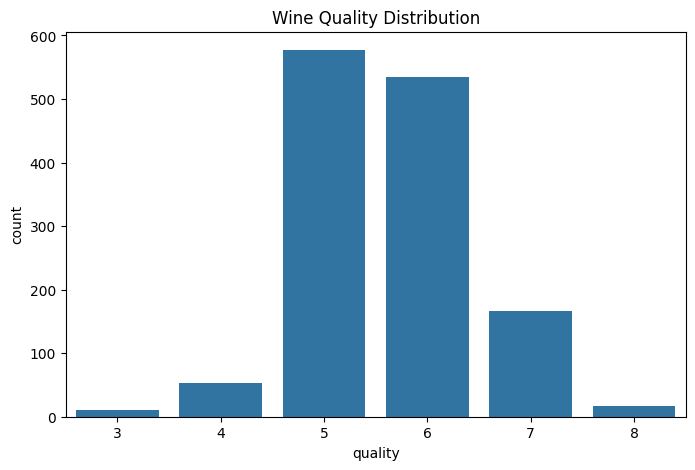

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='quality'
)

plt.title("Wine Quality Distribution")
plt.show()

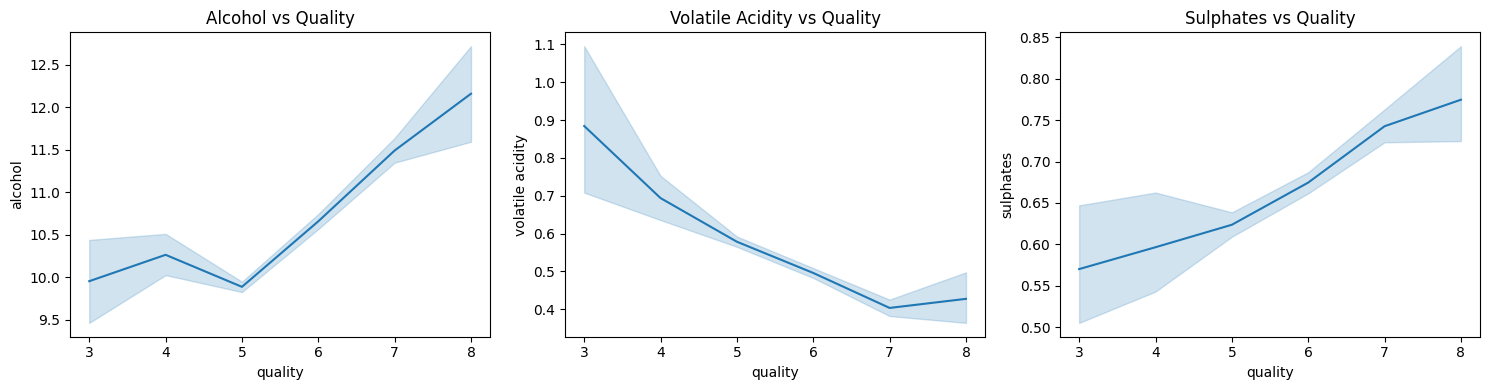

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=df, x="quality", y="alcohol", ax=axes[0])
axes[0].set_title("Alcohol vs Quality")

sns.lineplot(data=df, x="quality", y="volatile acidity", ax=axes[1])
axes[1].set_title("Volatile Acidity vs Quality")

sns.lineplot(data=df, x="quality", y="sulphates", ax=axes[2])
axes[2].set_title("Sulphates vs Quality")

plt.tight_layout()
plt.show()

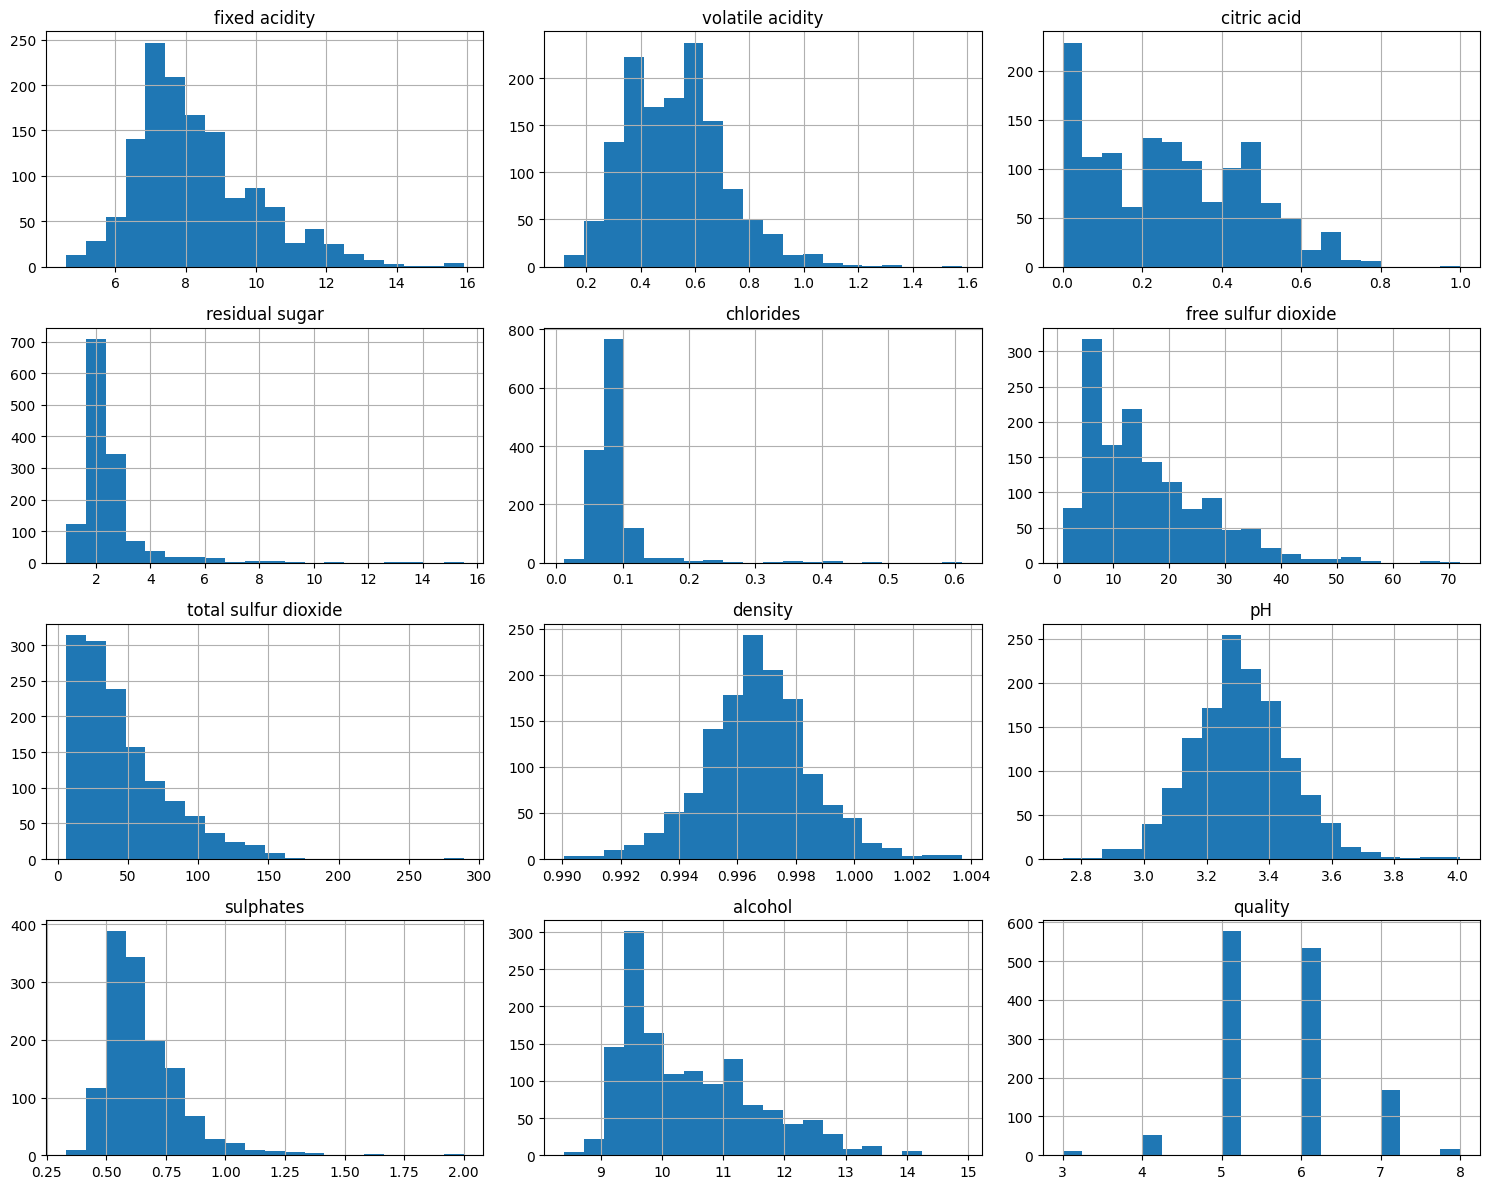

In [12]:
df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()
plt.show()

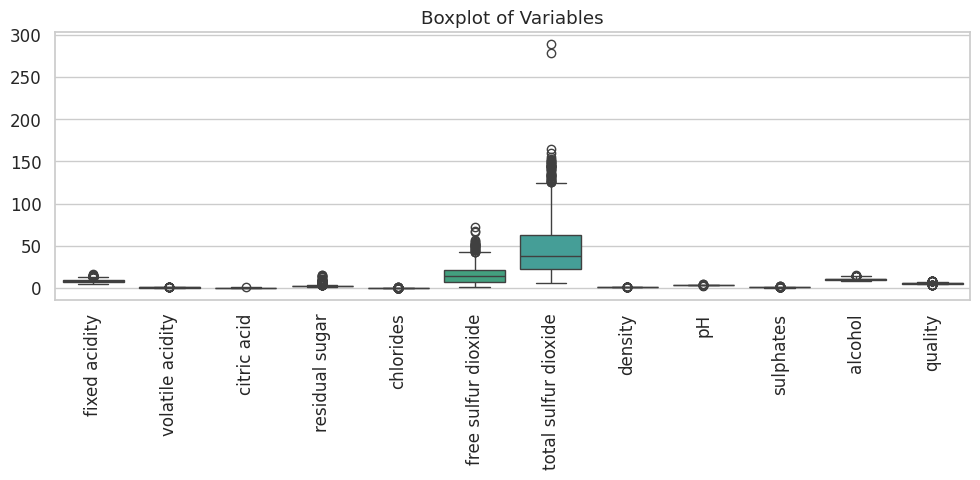

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: set a nice style and context
sns.set_theme(style="whitegrid", palette="pastel", font_scale=1.1)

plt.figure(figsize=(10, 5))

sns.boxplot(data=df)

plt.xticks(rotation=90)
plt.title("Boxplot of Variables")  
plt.tight_layout()                 

plt.show()

Key EDA Findings

No missing values.
Some duplicate records exist.

Quality scores mainly between 5 and 6.

Alcohol positively affects quality.

Volatile acidity negatively affects quality.

Several features contain outliers.

Dataset is slightly imbalanced.


# Regression Modeling

Regression is a supervised Machine Learning technique used to predict continuous numerical values.

In this section, we will build a Random Forest Regressor to predict the exact wine quality score based on the physicochemical properties of the wine.

The model's performance will be evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

In [14]:
X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
regressor = RandomForestRegressor(n_estimators=200, random_state=42)
regressor.fit(X_train, y_train)

pred = regressor.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("R2 :", r2_score(y_test, pred))

MAE: 0.4674448529411765
MSE: 0.3811065257352941
R2 : 0.46198436850039126


### Regression Model Evaluation

The Random Forest Regressor achieved the following results:

- MAE: 0.467
- MSE: 0.381
- R² Score: 0.462

Interpretation:

- The model's predictions differ from the actual wine quality score by approximately 0.47 points on average.
- The relatively low MSE indicates that large prediction errors are limited.
- The R² score of 0.462 suggests that the model explains about 46.2% of the variability in wine quality.

Overall, the model demonstrates moderate predictive performance and captures a meaningful portion of the relationship between physicochemical properties and wine quality.

**Classification Model**

In [26]:
df["good_wine"] = np.where(df["quality"] >= 6, 1, 0)

X = df.drop(["quality", "good_wine"], axis=1)
y = df["good_wine"]

print("Class distribution:\n", y.value_counts())

Class distribution:
 good_wine
1    719
0    640
Name: count, dtype: int64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


In [17]:
classifier = RandomForestClassifier(n_estimators=200, random_state=42)
classifier.fit(X_train_sm, y_train_sm)

pred = classifier.predict(X_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, pred))
print()
print(classification_report(y_test, pred))

Accuracy: 0.5992647058823529

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.15      0.18      0.17        11
           5       0.74      0.74      0.74       120
           6       0.60      0.48      0.53       103
           7       0.43      0.71      0.54        31
           8       0.17      0.33      0.22         3

    accuracy                           0.60       272
   macro avg       0.35      0.41      0.37       272
weighted avg       0.61      0.60      0.60       272



/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

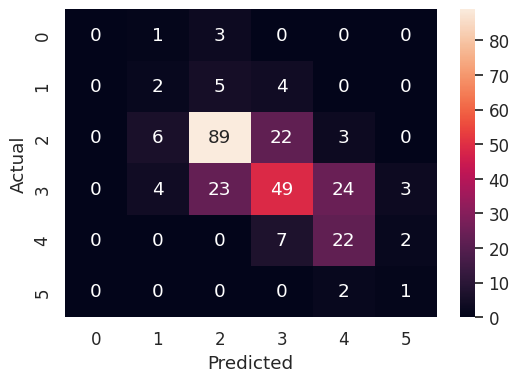

In [19]:
cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": classifier.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                 Feature  Importance
4              chlorides    0.133500
10               alcohol    0.127192
9              sulphates    0.108737
6   total sulfur dioxide    0.104234
1       volatile acidity    0.103384
3         residual sugar    0.079987
8                     pH    0.076976
5    free sulfur dioxide    0.070976
7                density    0.067348
2            citric acid    0.064896
0          fixed acidity    0.062769


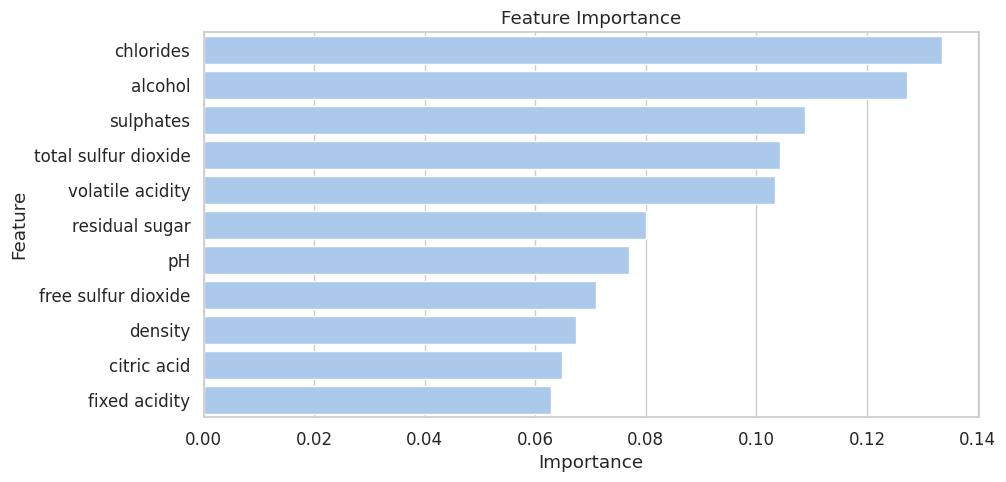

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [25]:
wine1 = pd.DataFrame({
    'fixed acidity': [7.4],
    'volatile acidity': [0.30],
    'citric acid': [0.34],
    'residual sugar': [1.9],
    'chlorides': [0.076],
    'free sulfur dioxide': [5.0],
    'total sulfur dioxide': [34.0],
    'density': [0.9978],
    'pH': [3.51],
    'sulphates': [0.66],
    'alcohol': [11.5]
})

wine2 = pd.DataFrame({
    'fixed acidity': [8.1],
    'volatile acidity': [0.70],
    'citric acid': [0.00],
    'residual sugar': [2.6],
    'chlorides': [0.098],
    'free sulfur dioxide': [25.0],
    'total sulfur dioxide': [67.0],
    'density': [0.9968],
    'pH': [3.20],
    'sulphates': [0.40],
    'alcohol': [9.2]
})

print("=" * 50)
for i, wine in enumerate([wine1, wine2], 1):
    quality = regressor.predict(wine)[0]
    category = "Good Wine" if classifier.predict(wine)[0] == 1 else "Not Good Wine"
    print(f"Wine {i}")
    print(f"  Regressor  → Predicted Quality : {quality:.2f}")
    print(f"  Classifier → Category          : {category}")
    print("-" * 50)

Wine 1
  Regressor  → Predicted Quality : 6.29
  Classifier → Category          : Not Good Wine
--------------------------------------------------
Wine 2
  Regressor  → Predicted Quality : 4.97
  Classifier → Category          : Not Good Wine
--------------------------------------------------
